In [1]:
print("helloworld")

helloworld


In [2]:
import numpy as np
import matplotlib.pyplot as plt


Implementation of the superfermion representation matrix of single mode fermion

In [3]:
def superfermion_operators():
    I = np.eye(2, dtype=complex)

    sm = np.array([[0, 1],
                   [0, 0]], dtype=complex)
    sp = sm.conj().T
    sz = np.array([[1, 0],
                   [0, -1]], dtype=complex)

    # first fermionic mode: physical c
    c = np.kron(sm, I)
    cd = c.conj().T

    # second fermionic mode: tilde c
    ct = np.kron(sz, sm)
    ctd = ct.conj().T

    return c, cd, ct, ctd, np.eye(4, dtype=complex)

def rosso_eq39_matrix(eps, Gamma1, Gamma2, hbar=1.0):
    c, cd, ct, ctd, I4 = superfermion_operators()

    n = cd @ c
    nt = ctd @ ct

    L = (
        eps * (n - nt)
        - 0.5j * hbar * (Gamma1 - Gamma2) * (n + nt)
        + hbar * (Gamma1 * (c @ ct) + Gamma2 * (cd @ ctd))
        - 1j * hbar * Gamma2 * I4
    )

    return L

def analytic_rosso_eigenvalues(eps, Gamma1, Gamma2, hbar=1.0):
    G = Gamma1 + Gamma2
    return np.array([
        0.0,
        -1j * hbar * G,
        eps - 0.5j * hbar * G,
        -eps - 0.5j * hbar * G,
    ], dtype=complex)

eps = 1.3
Gamma1 = 0.7
Gamma2 = 0.2
hbar = 1.0

L = rosso_eq39_matrix(eps, Gamma1, Gamma2, hbar=hbar)

num = np.linalg.eigvals(L)
ana = analytic_rosso_eigenvalues(eps, Gamma1, Gamma2, hbar=hbar)

print("Numerical:")
print(np.sort_complex(num))

print("\nAnalytic:")
print(np.sort_complex(ana))

Numerical:
[-1.30000000e+00-4.50000000e-01j  0.00000000e+00+3.12250226e-17j
  2.77555756e-17-9.00000000e-01j  1.30000000e+00-4.50000000e-01j]

Analytic:
[-1.3-0.45j  0. -0.9j   0. +0.j    1.3-0.45j]


Reimplementing the code for full numerical treatment of random matrices

In [4]:
def split_diagonal_offdiagonal(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Split a matrix A into:
        D = diagonal part
        V = off-diagonal part
    so that A = D + V
    """
    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("matrix must be a square 2D array")

    D = np.diag(np.diag(matrix))
    V = matrix - D
    return D, V


def drop_small_offdiagonals(
    matrix: np.ndarray,
    original_matrix: np.ndarray,
    threshold: float = 0.01,
    atol: float = 0.0
) -> np.ndarray:
    """
    Zero out off-diagonal entries of `matrix` if

        |matrix[i,j]| < threshold * |original_matrix[i,j]|

    or, additionally, if

        |matrix[i,j]| < atol

    Diagonal entries are left unchanged.
    """
    if matrix.shape != original_matrix.shape:
        raise ValueError("matrix and original_matrix must have the same shape")

    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("matrix and original_matrix must be square 2D arrays")

    result = matrix.copy()
    n = matrix.shape[0]

    for i in range(n):
        for j in range(n):
            if i != j:
                if (
                    np.abs(result[i, j]) < threshold * np.abs(original_matrix[i, j])
                    or np.abs(result[i, j]) < atol
                ):
                    result[i, j] = 0.0

    return result


def commutator(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    return A @ B - B @ A


def split_diagonal_offdiagonal(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    A = D + V
    D: diagonal part
    V: off-diagonal part
    """
    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("matrix must be a square 2D array")

    D = np.diag(np.diag(matrix))
    V = matrix - D
    return D, V


def eta_first(A: np.ndarray) -> np.ndarray:
    """
    First Rosso generator:
        eta_1 = [A^\dagger, V]
    """
    _, V = split_diagonal_offdiagonal(A)
    return commutator(A.conj().T, V)


def eta_second(A: np.ndarray) -> np.ndarray:
    """
    Second Rosso generator:
        eta_2 = [D^\dagger, V]
    """
    D, V = split_diagonal_offdiagonal(A)
    return commutator(D.conj().T, V)


def eta_third(A: np.ndarray, eps: float = 1e-14) -> np.ndarray:
    """
    Third Rosso/White-like generator:
        eta_3[n,k] = V[n,k] / (D[n,n] - D[k,k])   if denominator != 0
                   = 0                            otherwise

    The diagonal is zero automatically because V has zero diagonal.
    """
    D, V = split_diagonal_offdiagonal(A)
    diag = np.diag(D)
    n = A.shape[0]

    eta = np.zeros_like(A, dtype=np.complex128)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            denom = diag[i] - diag[j]
            if np.abs(denom) > eps:
                eta[i, j] = V[i, j] / denom
            else:
                eta[i, j] = 0.0

    return eta


def get_eta(A: np.ndarray, generator: str = "first", eps: float = 1e-14) -> np.ndarray:
    """
    Dispatch function for generator choice.

    Allowed values:
        'first'  -> eta_1 = [A^\dagger, V]
        'second' -> eta_2 = [D^\dagger, V]
        'third'  -> eta_3[n,k] = V[n,k] / (D_nn - D_kk)
    """
    generator = generator.lower()

    if generator == "first":
        return eta_first(A)
    elif generator == "second":
        return eta_second(A)
    elif generator == "third":
        return eta_third(A, eps=eps)
    else:
        raise ValueError(
            "Unknown generator. Choose from {'first', 'second', 'third'}."
        )


def flow_rhs(A: np.ndarray, generator: str = "first", eps: float = 1e-14) -> np.ndarray:
    """
    Flow equation RHS:
        dA/dl = [eta(A), A]
    """
    eta = get_eta(A, generator=generator, eps=eps)
    return commutator(eta, A)


def rk4_step(f, y: np.ndarray, h: float, **f_kwargs) -> np.ndarray:
    k1 = f(y, **f_kwargs)
    k2 = f(y + 0.5 * h * k1, **f_kwargs)
    k3 = f(y + 0.5 * h * k2, **f_kwargs)
    k4 = f(y + h * k3, **f_kwargs)

    return y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def initialize_diagonal_tracker(n: int) -> dict:
    """
    Create a container to store the flow of diagonal entries.

    Parameters
    ----------
    n : int
        Matrix dimension.

    Returns
    -------
    dict
        Tracker dictionary for storing flow data.
    """
    return {
        "l_values": [],
        "diag_real": [[] for _ in range(n)],
        "diag_imag": [[] for _ in range(n)],
    }


def record_diagonal_step(tracker: dict, A: np.ndarray, l: float) -> None:
    """
    Record the diagonal entries of the current matrix A at flow parameter l.

    Parameters
    ----------
    tracker : dict
        Tracker created by initialize_diagonal_tracker.
    A : np.ndarray
        Current matrix.
    l : float
        Current flow parameter.
    """
    diag = np.diag(A)
    tracker["l_values"].append(l)

    for i, val in enumerate(diag):
        tracker["diag_real"][i].append(val.real)
        tracker["diag_imag"][i].append(val.imag)


def plot_diagonal_flow(tracker: dict,
                       figsize: tuple[float, float] = (8, 6),
                       show_legend: bool = False,
                       title_prefix: str = "Diagonal flow") -> None:
    """
    Plot the real and imaginary parts of the diagonal entries in two separate plots.

    Parameters
    ----------
    tracker : dict
        Tracker containing recorded diagonal flow data.
    figsize : tuple
        Figure size for each plot.
    show_legend : bool
        Whether to show a legend for each diagonal element.
    title_prefix : str
        Prefix for plot titles.
    """
    l_values = np.array(tracker["l_values"])
    diag_real = tracker["diag_real"]
    diag_imag = tracker["diag_imag"]

    # Plot real parts
    plt.figure(figsize=figsize)
    for i, y in enumerate(diag_real):
        label = rf"$\mathrm{{Re}}\,A_{{{i+1}{i+1}}}$" if show_legend else None
        plt.plot(l_values, y, label=label)
    plt.xlabel(r"$\ell$")
    plt.ylabel("Real part of diagonal entries")
    plt.title(f"{title_prefix}: real parts")
    if show_legend:
        plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    # Plot imaginary parts
    plt.figure(figsize=figsize)
    for i, y in enumerate(diag_imag):
        label = rf"$\mathrm{{Im}}\,A_{{{i+1}{i+1}}}$" if show_legend else None
        plt.plot(l_values, y, label=label)
    plt.xlabel(r"$\ell$")
    plt.ylabel("Imaginary part of diagonal entries")
    plt.title(f"{title_prefix}: imaginary parts")
    if show_legend:
        plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

def solve_flow_rk4(
    A0: np.ndarray,
    dl: float = 1e-3,
    n_steps: int = 15000,
    threshold: float = 0.01,
    atol_drop: float = 0.0,
    generator: str = "first",
    eta_eps: float = 1e-14,
    track_diagonal: bool = False
):
    A = A0.astype(np.complex128).copy()
    A_initial = A.copy()

    tracker = initialize_diagonal_tracker(A.shape[0]) if track_diagonal else None
    if track_diagonal:
        record_diagonal_step(tracker, A, l=0.0)

    for step in range(n_steps):
        A = rk4_step(
            flow_rhs,
            A,
            dl,
            generator=generator,
            eps=eta_eps
        )

        A = drop_small_offdiagonals(
            A,
            A_initial,
            threshold=threshold,
            atol=atol_drop
        )

        if track_diagonal:
            current_l = (step + 1) * dl
            record_diagonal_step(tracker, A, l=current_l)

    return A, tracker

running the full numerical tracking vs np solve vs analytic 

In [5]:
L_first, tracker_first = solve_flow_rk4(
    L,
    generator="first",
    track_diagonal=True
)

L_second, tracker_second = solve_flow_rk4(
    L,
    generator="second",
    track_diagonal=True
)

L_third, tracker_third = solve_flow_rk4(
    L,
    generator="third",
    track_diagonal=True
)
#plot_diagonal_flow(tracker_first, title_prefix="First generator")
#plot_diagonal_flow(tracker_second, title_prefix="Second generator")
#plot_diagonal_flow(tracker_third, title_prefix="Third generator")

Note to self, due to the way that rosso uses the superfermion representation, his eigenvalues switch real and imaginary parts, which can cause confusion


In [6]:
print(np.diag(L_first))
print(np.diag(L_second))
print(np.diag(L_third))

[ 0. -3.84732539e-05j -1.3-4.50000000e-01j  1.3-4.50000000e-01j
  0. -8.99961527e-01j]
[ 0. -1.55310272e-05j -1.3-4.50000000e-01j  1.3-4.50000000e-01j
  0. -8.99984469e-01j]
[ 0. -1.55300285e-05j -1.3-4.50000000e-01j  1.3-4.50000000e-01j
  0. -8.99984470e-01j]


Trying to reproduce the Dissipative scatterig model

In [7]:
def quadratic_fermion_H_ordered(N, v=1.0, L=2*np.pi, hbar=1.0):
    """
    Single-particle coefficient matrix H for

        H_hat = sum_n epsilon_n c_n^\dagger c_n

    with linear dispersion epsilon_n = hbar*v*(2*pi/L)*n.

    N: cutoff, modes n=-N,...,N
    returns H, ns, eps
    """
    ns = np.arange(-N, N + 1)
    eps = hbar * v * (2*np.pi / L) * ns

    H = np.diag(eps.astype(complex))
    return H, ns, eps


def Mprime_ordered_scattering(N, gamma, v=1.0, L=2*np.pi, hbar=1.0):
    """
    First block M' = H - i*hbar/2 * Lambda_1
    for the ordered dissipative scattering model.
    """
    H, ns, eps = quadratic_fermion_H_ordered(N, v=v, L=L, hbar=hbar)

    D = 2*N + 1
    Lambda1 = (hbar * gamma / L) * np.ones((D, D), dtype=complex)

    Mprime = H - 0.5j * hbar * Lambda1
    return Mprime, H, ns, eps

Brute force implementation where each commutator is calculated explicitly (which is admittedly stupid snce it adds unnecessary computational cost)

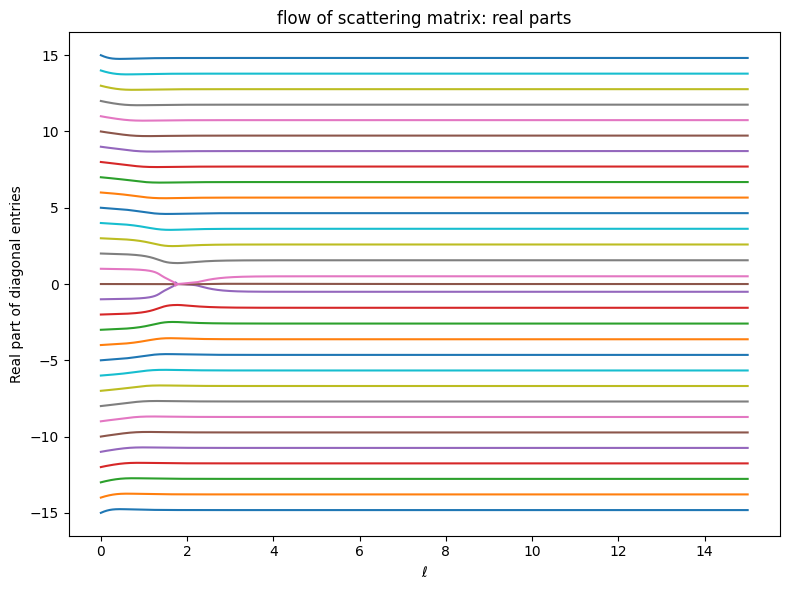

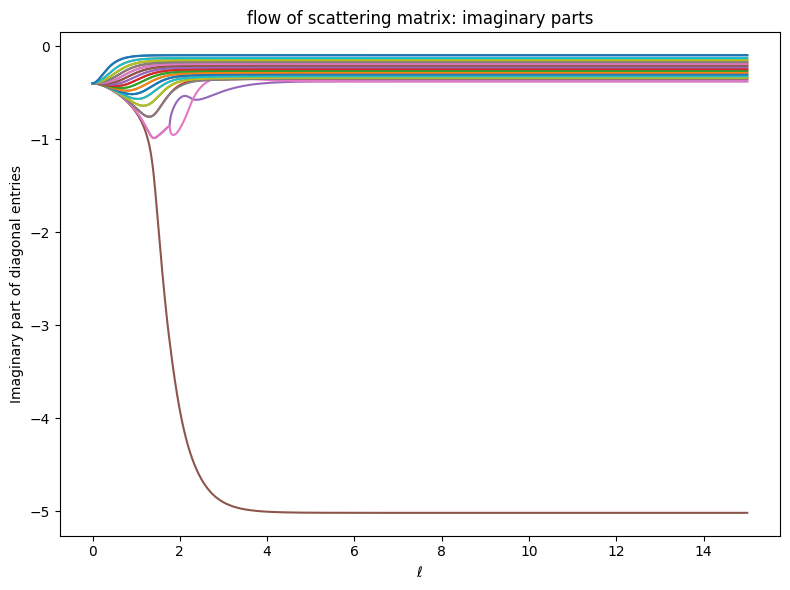

In [8]:
"""
Implementing the matrix flow from rosso with v=1, j = 15, gamma=5
    
"""
N = 15
gamma = 5.0

M, H, ns, eps = Mprime_ordered_scattering(N, gamma)

Scatering_M, tracker_third_scattering = solve_flow_rk4(
    M,
    generator="third",
    track_diagonal=True
)


plot_diagonal_flow(tracker_third_scattering, title_prefix="flow of scattering matrix")

In [10]:
def kron(a, b):
    return np.kron(a, b)

def liouvillian_sa_convention(H, jumps):
    """
    Sá-Ribeiro-Prosen / doubled-Hilbert-space convention.

    Vectorization:
        |rho>> = sum_ij rho_ij |i> tensor |j>*.

    Mapping:
        A rho B^\dagger -> (A tensor B*) |rho>>

    Lindblad convention used here:
        d rho / dt = -i[H,rho] 
                   + sum_j (J rho J^\dagger - 1/2 {J^\dagger J, rho})
    """
    d = H.shape[0]
    I = np.eye(d, dtype=complex)

    Lmat = -1j * (kron(H, I) - kron(I, H.conj()))

    for J in jumps:
        JdagJ = J.conj().T @ J

        Lmat += (
            kron(J, J.conj())
            - 0.5 * kron(JdagJ, I)
            - 0.5 * kron(I, JdagJ.conj())
        )

    return Lmat

def open_dicke_4d_sa(
    wc=1.0,
    w0=1.0,
    g=0.2,
    kappa=0.1,
    gamma=0.0,
    gamma_phi=0.0,
    model="rabi",
):
    """
    Basis:
        |0,dn>, |0,up>, |1,dn>, |1,up>

    Hilbert space:
        photon cutoff n=0,1 tensor spin-1/2
    """

    Iph = np.eye(2, dtype=complex)
    Is = np.eye(2, dtype=complex)

    a_ph = np.array([[0, 1],
                     [0, 0]], dtype=complex)
    adag_ph = a_ph.conj().T
    n_ph = adag_ph @ a_ph

    sx = np.array([[0, 1],
                   [1, 0]], dtype=complex)
    sz = np.array([[-1, 0],
                   [0,  1]], dtype=complex)

    # spin basis: |dn>, |up>
    sp = np.array([[0, 0],
                   [1, 0]], dtype=complex)  # |up><dn|
    sm = np.array([[0, 1],
                   [0, 0]], dtype=complex)  # |dn><up|

    a = kron(a_ph, Is)
    adag = kron(adag_ph, Is)
    n = kron(n_ph, Is)

    Sx = kron(Iph, sx)
    Sz = kron(Iph, sz)
    Sp = kron(Iph, sp)
    Sm = kron(Iph, sm)

    H0 = wc * n + 0.5 * w0 * Sz

    if model == "rabi":
        H_int = g * (a + adag) @ Sx
    elif model == "jc":
        H_int = g * (adag @ Sm + a @ Sp)
    else:
        raise ValueError("model must be 'rabi' or 'jc'")

    H = H0 + H_int

    jumps = []

    if kappa != 0:
        jumps.append(np.sqrt(kappa) * a)

    if gamma != 0:
        jumps.append(np.sqrt(gamma) * Sm)

    if gamma_phi != 0:
        jumps.append(np.sqrt(gamma_phi) * Sz)

    Lmat = liouvillian_sa_convention(H, jumps)

    return Lmat, H, jumps

    # dissipators
    for J in jumps:
        JdagJ = J.conj().T @ J
        Lmat += (
            kron(J.conj(), J)
            - 0.5 * kron(I, JdagJ)
            - 0.5 * kron(JdagJ.T, I)
        )

    return Lmat, H, jumps

def check_liouvillian_action(H, jumps):
    d = H.shape[0]
    Lmat = liouvillian_sa_convention(H, jumps)

    # random test density matrix, not necessarily physical
    rho = np.random.randn(d, d) + 1j * np.random.randn(d, d)

    rho_dot_direct = -1j * (H @ rho - rho @ H)

    for J in jumps:
        JdagJ = J.conj().T @ J
        rho_dot_direct += (
            J @ rho @ J.conj().T
            - 0.5 * (JdagJ @ rho + rho @ JdagJ)
        )

    rho_dot_vec = Lmat @ rho.reshape(-1, order="C")
    rho_dot_matrix = rho_dot_vec.reshape((d, d), order="C")

    return np.linalg.norm(rho_dot_direct - rho_dot_matrix)


In [12]:
Dicke_L, H_L, jumps_L = open_dicke_4d_sa()
print(check_liouvillian_action(H_L, jumps_L))

4.871083751574258e-16


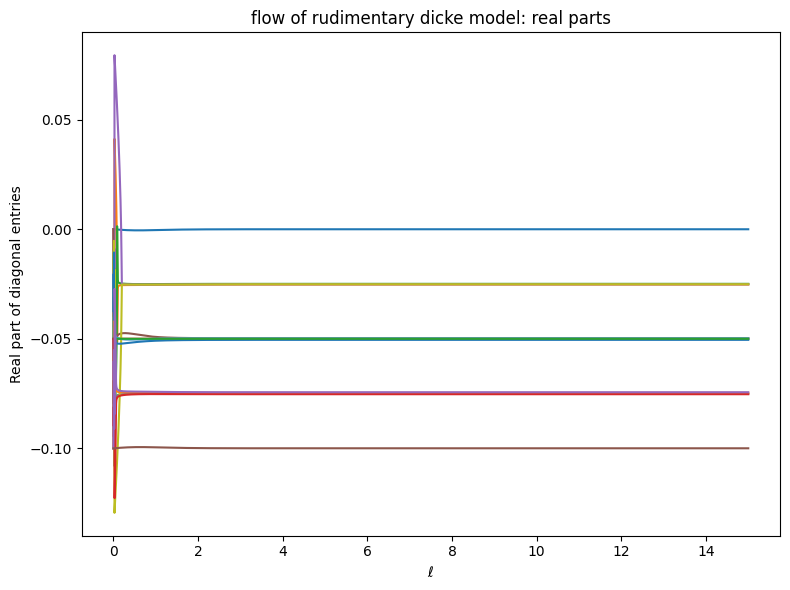

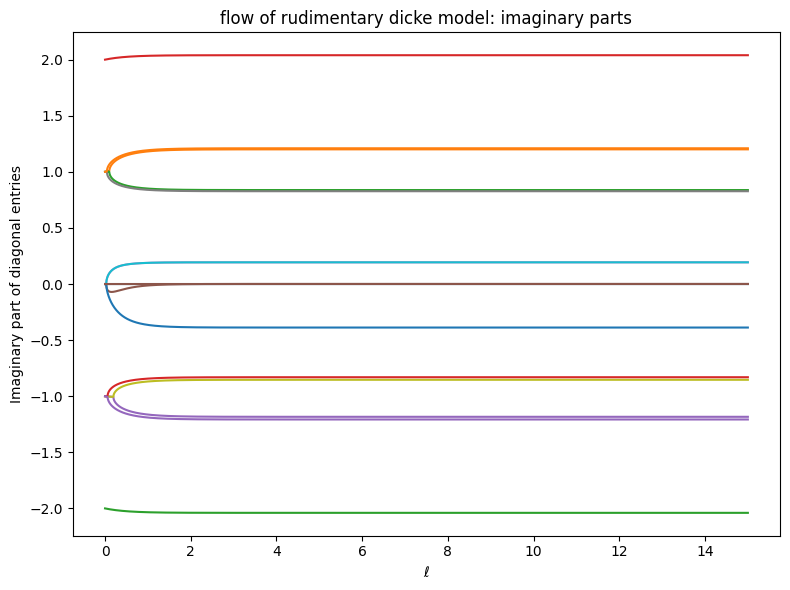

In [13]:
Scatering_dicke, tracker_dicke = solve_flow_rk4(
    Dicke_L,
    generator="third",
    track_diagonal=True
)


plot_diagonal_flow(tracker_dicke, title_prefix="flow of rudimentary dicke model")